In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from siaqua.visualization.plots import linear_graph
from siaqua.visualization.colors import NEUTRALS, COLORS, PALETTES
from siaqua.io.csv import read_csv, save_dataframe

### Teste dataset interim_caj_5m1d Chronos2 trainw = 385*12 ; step = 24 * 12 ; horizon = 2 * 24 *12

#### Linear Graph yhat x ytrue

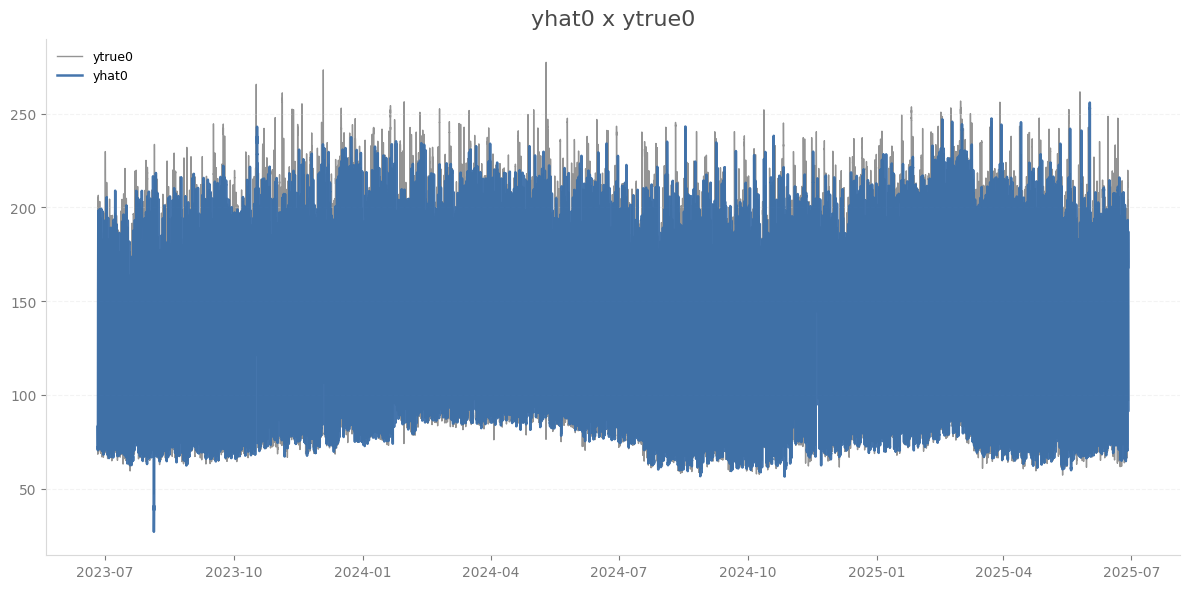

In [4]:
df = pd.read_csv("/home/wagner-barbosa/Documents/IC/output_models/output_chronos/chronos_forecast/results_chronos_2026-09-15-23-21-03.csv")

linear_graph(df, "timestamp", "yhat0", compare_cols=["ytrue0"])

#### Visualização grafico de erro - dispersão

[ 1.63117803  1.35220564  1.21889521  1.2661465   1.35045771  1.47744958
  1.59813022  1.82440933  2.06341144  2.28378004  2.47295642  2.67140173
  2.75259815  2.81533418  2.69624429  2.70870991  2.44489877  2.38567821
  2.39015021  2.36454254  2.37578551  2.37667773  2.42252657  2.51689331
  2.68278346  2.66232378  2.78651925  2.77535542  2.79386346  2.76124404
  2.6903509   2.6219847   2.56957933  2.59132433  2.67578086  2.59726396
  2.63651706  2.69295703  2.7575031   2.84262779  2.95199256  3.0151963
  3.1386254   3.19084029  3.22589604  3.26901086  3.26020101  3.25861127
  3.60602827  3.58099744  3.68239158  3.83022878  3.93805121  4.18704389
  4.46797349  4.75904923  5.01891646  5.45276102  5.77250532  6.09496302
  6.64166608  7.39848835  8.01380269  8.60477231  9.49494043 10.2827454
 10.95701511 11.38514954 12.05179291 12.77018887 13.15757251 13.23351733
 13.31883074 13.55367718 13.68955105 13.73065935 13.6503042  13.52828736
 13.29990365 13.02491905 12.05742987 11.70364407 11.3

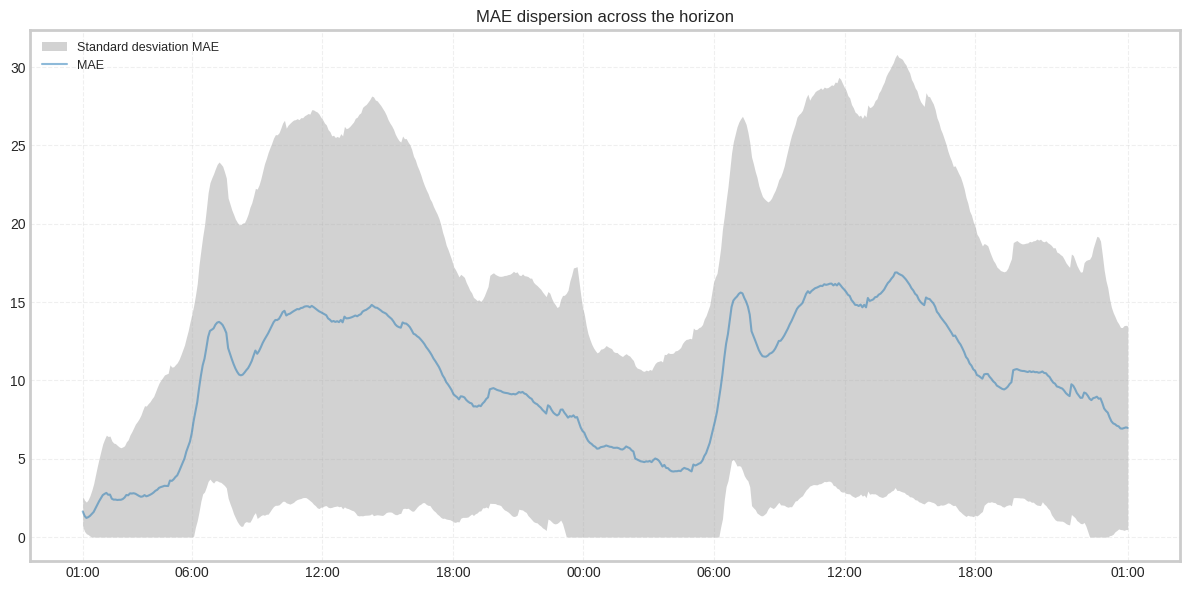

In [7]:
ae = np.zeros(576)
ae_sq = np.zeros(576) 
max = np.zeros(576)
min = np.zeros(576)

k = 0

for i in range(0, len(df), 288):
    for j in range(288):

        if i + 288 > len(df):
            break

        error0 = np.abs(df["ytrue0"].at[i+j] - df["yhat0"].at[i+j])
        error1 = np.abs(df["ytrue1"].at[i+j] - df["yhat1"].at[i+j])

        ae[j] += error0
        ae[j+288] += error1

        ae_sq[j] += error0**2
        ae_sq[j+288] += error1**2

        if max[j] < error0:
            max[j] = error0

        if max[j+288] < error1:
            max[j+288] = error1

        if min[j] > error0 or min[j] == 0:
            min[j] = error0

        if min[j+288] > error1 or min[j+288] == 0:
            min[j+288] = error1

    k += 1


MAX = max
MIN = min

MAE = ae / k

# NOVO: desvio padrão do erro absoluto
STD = np.sqrt(ae_sq / k - MAE**2)

print(MAE)

plt.style.use("seaborn-v0_8-whitegrid")


# plot
fig, ax = plt.subplots(figsize=(12, 6))

ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_linewidth(2)
ax.spines["top"].set_linewidth(2)
ax.spines["right"].set_linewidth(2)

ax.set_title("MAE dispersion across the horizon")

x_label = np.linspace(0, 576, 576)

ax.grid(axis="x", alpha=0.3, linestyle="--")
ax.grid(axis="y", linestyle="--", alpha=0.3)

ax.fill_between(
    x_label,
    np.maximum(MAE - STD, 0),
    MAE + STD,
    alpha=.5,
    linewidth=0,
    color=NEUTRALS.get("light"),
    label="Standard desviation MAE"
)

ax.plot(
    x_label,
    MAE,
    alpha=.5,
    linewidth=1.5,
    label="MAE",
    color=NEUTRALS.get("blue")
)

ax.legend(frameon=False, loc="upper left", fontsize=9)

ax.set_xticks([0, 60, 132, 204, 276, 348, 420, 492, 576])
ax.set_xticklabels([
    "01:00",
    "06:00",
    "12:00",
    "18:00",
    "00:00",
    "06:00",
    "12:00",
    "18:00",
    "01:00"
])

plt.tight_layout()

#### Error Bar

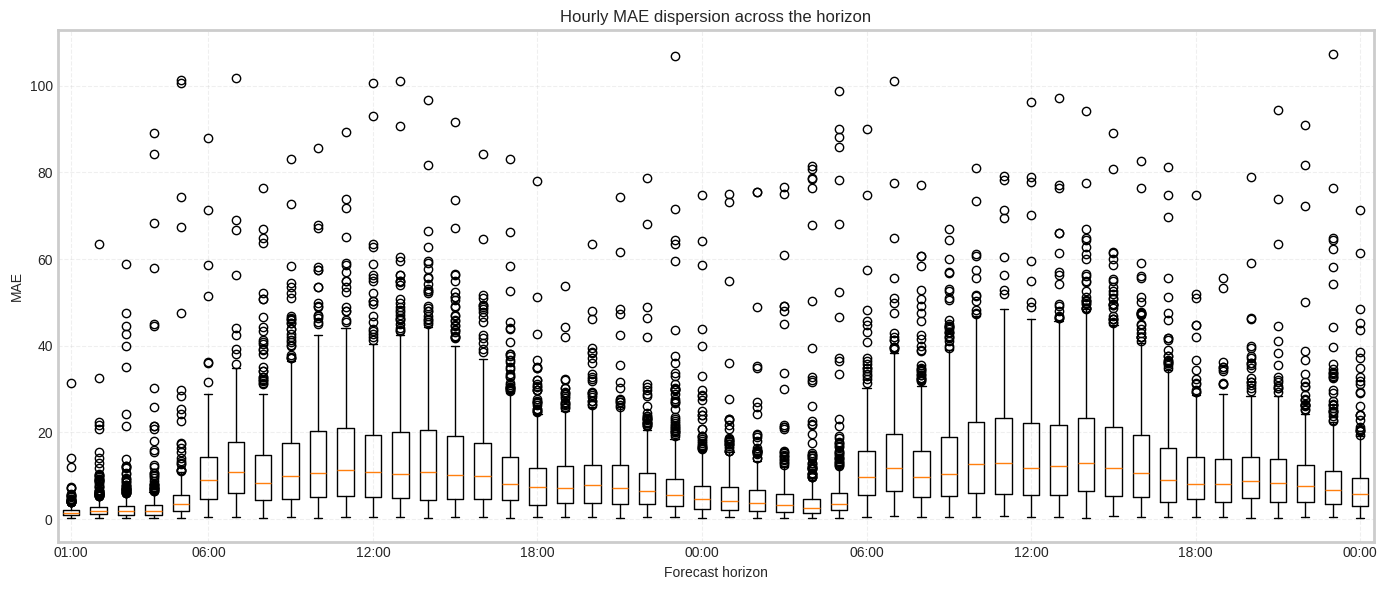

In [10]:
hourly_errors = [[] for _ in range(48)]

for i in range(0, len(df), 288):

    if i + 288 > len(df):
        break

    for hour in range(24):

        start = i + hour * 12
        end = start + 12

        # erro absoluto dos 12 pontos de 5 min daquela hora
        error0 = np.abs(df["ytrue0"].iloc[start:end].to_numpy()- df["yhat0"].iloc[start:end].to_numpy())

        error1 = np.abs(df["ytrue1"].iloc[start:end].to_numpy()- df["yhat1"].iloc[start:end].to_numpy())

        hourly_errors[hour].append(np.mean(error0))
        hourly_errors[hour + 24].append(np.mean(error1))


plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(14, 6))

ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_linewidth(2)
ax.spines["top"].set_linewidth(2)
ax.spines["right"].set_linewidth(2)

ax.set_title("Hourly MAE dispersion across the horizon")

ax.grid(axis="x", alpha=0.3, linestyle="--")
ax.grid(axis="y", linestyle="--", alpha=0.3)

ax.boxplot(
    hourly_errors,
    positions=np.arange(48),
    widths=0.6,
    showfliers=True
)

ax.set_xticks([0, 5, 11, 17, 23, 29, 35, 41, 47])

ax.set_xticklabels([
    "01:00",
    "06:00",
    "12:00",
    "18:00",
    "00:00",
    "06:00",
    "12:00",
    "18:00",
    "00:00"
])

ax.set_xlabel("Forecast horizon")
ax.set_ylabel("MAE")

plt.tight_layout()
plt.show()

### EDA

In [6]:
df = read_csv("Nelson_Brandao_tratado_5min_com_dias.csv", "interim")
linear_graph(df, output_type="eda", timestamp_col="datetime", highlight_col="vazao", filename="graph_nb_5min_w_days.png", title="graph_nb_5min_w_days")

df_res = read_csv("caj_merged_5min_1hour_features.csv", "interim")

print(df_res[["datetime", "day_sin", "day_cos"]].head())


                    datetime   day_sin   day_cos
0  2023-06-10 00:00:00+00:00  0.000000  1.000000
1  2023-06-10 00:05:00+00:00  0.021815  0.999762
2  2023-06-10 00:10:00+00:00  0.043619  0.999048
3  2023-06-10 00:15:00+00:00  0.065403  0.997859
4  2023-06-10 00:20:00+00:00  0.087156  0.996195


In [7]:
df_5min = pd.read_csv("/home/wagner-barbosa/Documents/IC/siaqua/data/interim/Nelson_Brandao_tratado_5min_com_dias.csv")
df_1hour = pd.read_csv("/home/wagner-barbosa/Documents/IC/siaqua/data/raw/23_06_10-25_06_30-request-open-meteo.csv")
df_1day = pd.read_csv("/home/wagner-barbosa/Documents/IC/siaqua/data/interim/dataset_all_features_engineering.csv")

df_5min["datetime"] = (pd.to_datetime(df_5min["datetime"], utc=True))
df_1hour["date"] = pd.to_datetime(df_1hour["date"], utc=True)
df_1day["timestamp"] = (pd.to_datetime(df_1day["timestamp"], utc=True))

df_5min = df_5min.sort_values("datetime")
df_1hour = df_1hour.sort_values("date")
df_1day = df_1day.sort_values("timestamp")

y = df_5min["datetime"].dt.hour

df_5min["teste"] = y

df_5min.to_csv("teste.csv")

print(df_5min["datetime"].dt.minute)

#df_5min["day"] = (df_5min["datetime"].dt.hour * 24 + df_5min["datetime"].dt.minute) // 5

0          0
1          5
2         10
3         15
4         20
          ..
216571    35
216572    40
216573    45
216574    50
216575    55
Name: datetime, Length: 216576, dtype: int32
